# MVPC Analysis on MIMIC Dataset

## Objective

This notebook evaluates the MVPC algorithm on real clinical data from the MIMIC-III dataset.  
We examine the structure of lab measurements and demographic variables under different simulated missingness scenarios.

## Data

- The aggregated mimic dataset is used, and the variables included were lab values (`Sodium`, `Potassium`, etc.) and demographics (`anchor_age`, `length_of_stay_hours`).
- Missingness is synthetically injected according to MAR and MNAR mechanisms using `create_mar_ind()` and `create_mnar_ind()`.
- The missingness structure is informed by plausible parent-child relationships between variables.

## Overview

1. For each sample size and repetition:
   - Draw a bootstrap sample from the MIMIC data
   - Inject MAR and MNAR missingness
   - Run MVPC with different CI test corrections (TD, PermC, DRW)
   - Compute skeleton properties (number of edges, density)
2. Aggregate results over repetitions
3. Visualize:
   - Edge density vs sample size
   - Edge frequency matrices for specific nodes
   - Neighborhood structure for key variables

## Outputs

- Plots of skeleton edge density as a function of sample size
- Heatmaps showing edge frequency matrices across repetitions
- Tables summarizing edge frequency per variable

In [1]:
import sys
import os


project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added:", project_root)

Project root added: /home/zervaki/Thesis_New


In [2]:
%load_ext autoreload
%autoreload 2

import sys
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from mvpc.mvpc_pipeline import MVPC

from mvpc.ci_tests.gauss_permc import gauss_ci_td, gauss_ci_permc
from mvpc.ci_tests.gauss_drw import gauss_ci_drw

from data.synthetic_data_generation.missingness_synthetic import (
    create_mar_ind, create_mnar_ind,
    generate_missing_values
)

mvpc_vars = [
    "Sodium", "Potassium", "Chloride", "Creatinine", "Urea Nitrogen",
    "Hematocrit", "Hemoglobin", "WBC", "Platelet Count", "Glucose",
    "anchor_age", "length_of_stay_hours",
]

df = pd.read_csv("../data/processed_mimic/processed_mimic_24h_labs_demographics.csv")
mimic_data = df[mvpc_vars].dropna().reset_index(drop=True)

num_var = len(mvpc_vars)
idx = {v: i for i, v in enumerate(mvpc_vars)}

print(mimic_data.shape)
mimic_data.head()


(35, 12)


,Sodium,Potassium,Chloride,Creatinine,Urea Nitrogen,Hematocrit,Hemoglobin,WBC,Platelet Count,Glucose,anchor_age,length_of_stay_hours
0,126.0,5.20,92.0,0.3,29.0,35.50,12.40,13.0,137.0,71.0,52,24.366667
1,136.0,3.65,102.0,1.3,10.0,30.35,9.75,1.0,249.0,113.5,47,40.316667
2,140.0,4.40,103.0,0.8,20.0,39.90,13.50,1.0,192.0,87.0,78,240.083333
3,145.0,3.40,108.0,3.4,44.0,30.60,10.15,17.0,186.0,93.0,51,554.533333
4,141.0,3.05,100.0,1.0,23.5,27.45,8.60,28.0,414.0,145.0,66,205.350000


In [3]:
adj_for_missing = np.zeros((num_var, num_var))

# missingness parents
adj_for_missing[idx["Sodium"], idx["Creatinine"]] = 1
adj_for_missing[idx["Potassium"], idx["Creatinine"]] = 1

adj_for_missing[idx["Sodium"], idx["Glucose"]] = 1
adj_for_missing[idx["Chloride"], idx["Glucose"]] = 1

adj_for_missing[idx["Creatinine"], idx["Urea Nitrogen"]] = 1
adj_for_missing[idx["Urea Nitrogen"], idx["WBC"]] = 1

adj_for_missing[idx["Hemoglobin"], idx["Hematocrit"]] = 1
adj_for_missing[idx["Hemoglobin"], idx["Platelet Count"]] = 1

adj_for_missing[idx["WBC"], idx["length_of_stay_hours"]] = 1
adj_for_missing[idx["anchor_age"], idx["length_of_stay_hours"]] = 1


In [4]:
from data.synthetic_data_generation.dag_and_data import (
    detect_colliders, detect_collider_parents
)

colliders = detect_colliders(adj_for_missing)
collider_parents = detect_collider_parents(adj_for_missing, colliders)


In [5]:
def edge_frequency_matrix(skeleton_list):
    k = skeleton_list[0].shape[0]
    F = np.zeros((k, k))
    R = len(skeleton_list)
    for S in skeleton_list:
        F += S
    F /= R
    return F


In [ ]:
# X_full = mimic_data.to_numpy()

mvpc_td = MVPC(
    indep_test=gauss_ci_td,
    corr_test=gauss_ci_td,
    alpha=0.05
)

n_reps_ref = 20
skeletons_ref = []

for rep in range(n_reps_ref):
    X_boot = mimic_data.sample(len(mimic_data), replace=True, random_state=rep).to_numpy()
    out = mvpc_td.run(X_boot)
    G = out["G_corrected"]
    S = ((G + G.T) > 0).astype(int)
    skeletons_ref.append(S)

F_ref = edge_frequency_matrix(skeletons_ref)
threshold = 0.6
skeleton_ref = (F_ref >= threshold).astype(int)


[Step 1] m_inds (vars with NaNs): []


Detecting parents of missingness indicators: 0it [00:00, ?it/s]


[Step 1] m_inds_filtered (with ≥1 parent): []
[Step 1] prt dict: {}


[Step 1] m_inds (vars with NaNs): []


Detecting parents of missingness indicators: 0it [00:00, ?it/s]


...

Detecting parents of missingness indicators: 0it [00:00, ?it/s]


[Step 1] m_inds_filtered (with ≥1 parent): []
[Step 1] prt dict: {}


[Step 1] m_inds (vars with NaNs): []


Detecting parents of missingness indicators: 0it [00:00, ?it/s]


[Step 1] m_inds_filtered (with ≥1 parent): []
[Step 1] prt dict: {}


In [7]:
def compare_skeletons(S_est, S_ref):
    triu = np.triu_indices_from(S_ref, k=1)
    est = S_est[triu]
    ref = S_ref[triu]

    TP = np.sum((est == 1) & (ref == 1))
    FP = np.sum((est == 1) & (ref == 0))
    FN = np.sum((est == 0) & (ref == 1))

    precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else np.nan
    shd = FP + FN

    return dict(TP=TP, FP=FP, FN=FN,
                precision=precision, recall=recall,
                f1=f1, shd=shd)


In [ ]:
sample_sizes = [300, 400, 500, 1000]
n_reps = 50  

num_extra_e = 3
num_m = 6

p_missing_h = 0.9
p_missing_l = 0.1

modes = ["MAR", "MNAR"]
methods = ["td", "permc", "drw"]


In [9]:
all_runs = []  
all_skeletons = {}  


In [10]:
def add_skeleton(mode, method, n, skeleton):
    key = (mode, method, n)
    if key not in all_skeletons:
        all_skeletons[key] = []
    all_skeletons[key].append(skeleton)


In [ ]:
import gc

for n in sample_sizes:
    for rep in range(n_reps):

        
        X_complete = mimic_data.sample(n, replace=True, random_state=rep).to_numpy()
        
        out_td = mvpc_td.run(X_complete)
        G_td = out_td["G_corrected"]
        S_td = ((G_td + G_td.T) > 0).astype(int)

        # Generate missingness structures 
        ms_mar, prt_ms_mar = create_mar_ind(
            colliders, collider_parents, num_var,
            num_extra_e=num_extra_e, num_m=num_m, seed=rep
        )
        ms_mnar, prt_ms_mnar = create_mnar_ind(
            colliders, collider_parents, num_var,
            num_extra_e=num_extra_e, num_m=num_m, seed=rep
        )

        # Generate missing data
        X_mar = generate_missing_values(
            X_complete, ms_mar, prt_ms_mar,
            p_missing_h=p_missing_h, p_missing_l=p_missing_l, seed=rep
        )
        X_mnar = generate_missing_values(
            X_complete, ms_mnar, prt_ms_mnar,
            p_missing_h=p_missing_h, p_missing_l=p_missing_l, seed=rep
        )

        # MVPC for each method
        for mode, X_m in [("MAR", X_mar), ("MNAR", X_mnar)]:
            for method in methods:

                if method == "td":
                    mvpc = MVPC(indep_test=gauss_ci_td, corr_test=gauss_ci_td, alpha=0.05)
                elif method == "permc":
                    mvpc = MVPC(indep_test=gauss_ci_td, corr_test=gauss_ci_permc, alpha=0.05)
                elif method == "drw":
                    mvpc = MVPC(indep_test=gauss_ci_td, corr_test=gauss_ci_drw, alpha=0.05)

                out_mvpc = mvpc.run(X_m)
                G_mvpc = out_mvpc["G_corrected"]

                # Skeleton
                skeleton_mvpc = ((G_mvpc + G_mvpc.T) > 0).astype(int)
                num_edges = skeleton_mvpc.sum() / 2
                max_edges = num_var * (num_var - 1) / 2
                density = num_edges / max_edges
                
                comp = compare_skeletons(skeleton_mvpc, S_td)

                all_runs.append({
                    "mode": mode,
                    "method": method,
                    "n": n,
                    "rep": rep,
                    "num_edges": num_edges,
                    "density": density,
                    **comp
                })
                if n == 1000:   # or whichever you want to visualize
                    add_skeleton(mode, method, n, skeleton_mvpc)



        del out_mvpc, G_mvpc, skeleton_mvpc, ms_mar, prt_ms_mar, ms_mnar, prt_ms_mnar
        gc.collect()



NameError: name 'sample_sizes' is not defined

In [12]:
df_runs = pd.DataFrame(all_runs)

summary_metrics = (
    df_runs.groupby(["mode", "method", "n"])
           .agg(mean_f1=("f1", "mean"),
                sd_f1=("f1", "std"),
                mean_shd=("shd", "mean"),
                sd_shd=("shd", "std"),
                mean_precision=("precision", "mean"),
                mean_recall=("recall", "mean"))
           .reset_index()
)

summary_metrics



,mode,method,n,mean_f1,sd_f1,mean_shd,sd_shd,mean_precision,mean_recall
0,MAR,drw,300,0.575738,0.031017,8.90,1.119210,0.404872,1.0
1,MAR,drw,400,0.537750,0.042249,10.45,1.820208,0.368840,1.0
2,MAR,drw,500,0.515650,0.031639,11.35,1.348488,0.347988,1.0
3,MAR,drw,1000,0.445489,0.022267,15.00,1.337712,0.286831,1.0
4,MAR,permc,300,0.587487,0.037122,8.50,1.235442,0.416868,1.0
5,MAR,permc,400,0.542518,0.042415,10.25,1.773341,0.373336,1.0
6,MAR,permc,500,0.519516,0.036141,11.20,1.542384,0.351691,1.0
7,MAR,permc,1000,0.462897,0.025675,14.00,1.450953,0.301494,1.0
8,MAR,td,300,0.572731,0.028097,9.00,1.025978,0.401795,1.0
9,MAR,td,400,0.535085,0.039745,10.55,1.761429,0.366211,1.0


In [13]:
summary_density = (
    df_runs.groupby(["mode", "method", "n"])
           .agg(mean_edges=("num_edges", "mean"),
                mean_density=("density", "mean"),
                sd_density=("density", "std"))
           .reset_index()
)

summary_density


,mode,method,n,mean_edges,mean_density,sd_density
0,MAR,drw,300,14.90,0.225758,0.016958
1,MAR,drw,400,16.45,0.249242,0.027579
2,MAR,drw,500,17.35,0.262879,0.020432
3,MAR,drw,1000,21.00,0.318182,0.020268
4,MAR,permc,300,14.50,0.219697,0.018719
5,MAR,permc,400,16.25,0.246212,0.026869
6,MAR,permc,500,17.20,0.260606,0.023369
7,MAR,permc,1000,20.00,0.303030,0.021984
8,MAR,td,300,15.00,0.227273,0.015545
9,MAR,td,400,16.55,0.250758,0.026688


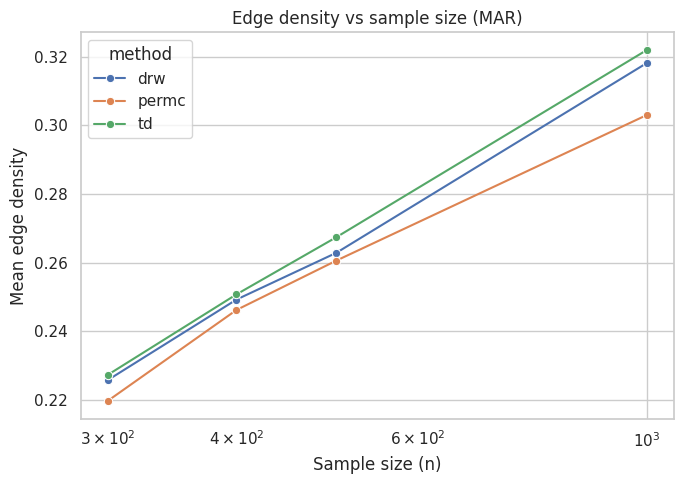

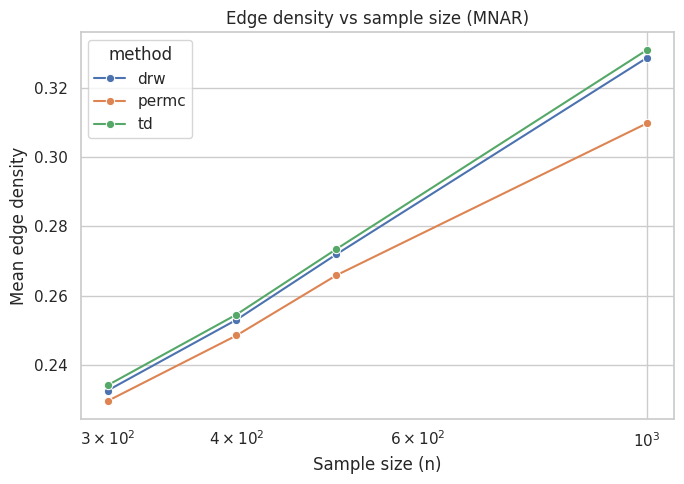

In [14]:
# density plots

for mode in ["MAR", "MNAR"]:
    plt.figure(figsize=(7, 5))
    sub = summary_density[summary_density["mode"] == mode]

    sns.lineplot(
        data=sub,
        x="n",
        y="mean_density",
        hue="method",
        marker="o"
    )

    plt.title(f"Edge density vs sample size ({mode})")
    plt.xlabel("Sample size (n)")
    plt.ylabel("Mean edge density")
    plt.xscale("log")
    plt.tight_layout()
    plt.show()


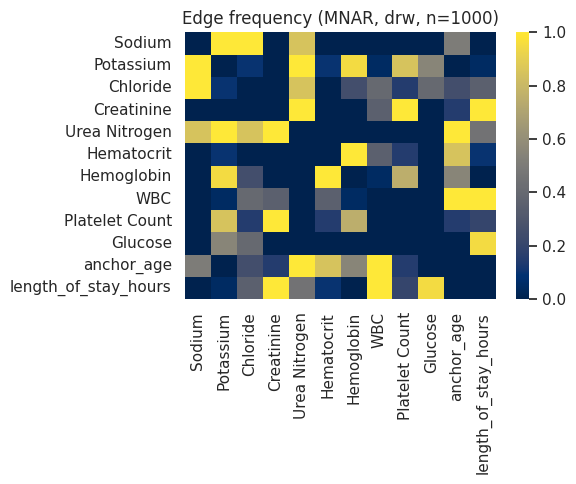

In [22]:
def edge_frequency_matrix(skeleton_list):
    k = skeleton_list[0].shape[0]
    F = np.zeros((k, k))
    R = len(skeleton_list)
    for S in skeleton_list:
        F += S
    F /= R
    return F

# Example: pick one setting
mode = "MNAR"
method = "drw"
n = 1000

F = edge_frequency_matrix(all_skeletons[(mode, method, n)])

plt.figure(figsize=(6, 5))
sns.heatmap(F, xticklabels=mvpc_vars, yticklabels=mvpc_vars, cmap="cividis", vmin=0, vmax=1)
plt.title(f"Edge frequency ({mode}, {method}, n={n})")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [34]:
target = "length_of_stay_hours"
j = idx[target]

def edge_freq_for_node(F, j, vars_list, threshold=0.5):
    res = []
    for i, v in enumerate(vars_list):
        if i == j:
            continue
        freq = F[i, j]
        res.append((v, freq))
    res.sort(key=lambda x: -x[1])
    return [r for r in res if r[1] >= threshold]

for mode in ["MAR", "MNAR"]:
    for method in methods:
        for n in [300, 1000]:
            F = edge_frequency_matrix(all_skeletons[(mode, method, n)])
            neigh = edge_freq_for_node(F, j, mvpc_vars, threshold=0.4)
            print(f"{mode}, {method}, n={n}:")
            for v, f in neigh:
                print(f"  {v}: {f:.2f}")
            print()


MAR, td, n=300:
  Creatinine: 1.00
  WBC: 1.00
  Urea Nitrogen: 0.95
  Glucose: 0.45

MAR, td, n=1000:
  Creatinine: 1.00
  WBC: 1.00
  Glucose: 1.00
  Urea Nitrogen: 0.55
  Chloride: 0.40

MAR, permc, n=300:
  Creatinine: 1.00
  WBC: 1.00
  Urea Nitrogen: 0.75
  Glucose: 0.45

MAR, permc, n=1000:
  Creatinine: 1.00
  WBC: 1.00
  Glucose: 1.00
  Urea Nitrogen: 0.55
  Chloride: 0.40

MAR, drw, n=300:
  Creatinine: 1.00
  WBC: 1.00
  Urea Nitrogen: 0.95
  Glucose: 0.45

MAR, drw, n=1000:
  Creatinine: 1.00
  WBC: 1.00
  Glucose: 1.00
  Urea Nitrogen: 0.50
  Chloride: 0.40

MNAR, td, n=300:
  Creatinine: 1.00
  WBC: 1.00
  Urea Nitrogen: 0.85

MNAR, td, n=1000:
  Creatinine: 1.00
  WBC: 1.00
  Glucose: 0.95
  Urea Nitrogen: 0.45

MNAR, permc, n=300:
  Creatinine: 1.00
  WBC: 1.00
  Urea Nitrogen: 0.80

MNAR, permc, n=1000:
  Creatinine: 1.00
  WBC: 1.00
  Glucose: 0.95
  Urea Nitrogen: 0.45

MNAR, drw, n=300:
  Creatinine: 1.00
  WBC: 1.00
  Urea Nitrogen: 0.80

MNAR, drw, n=1000:
  Creat

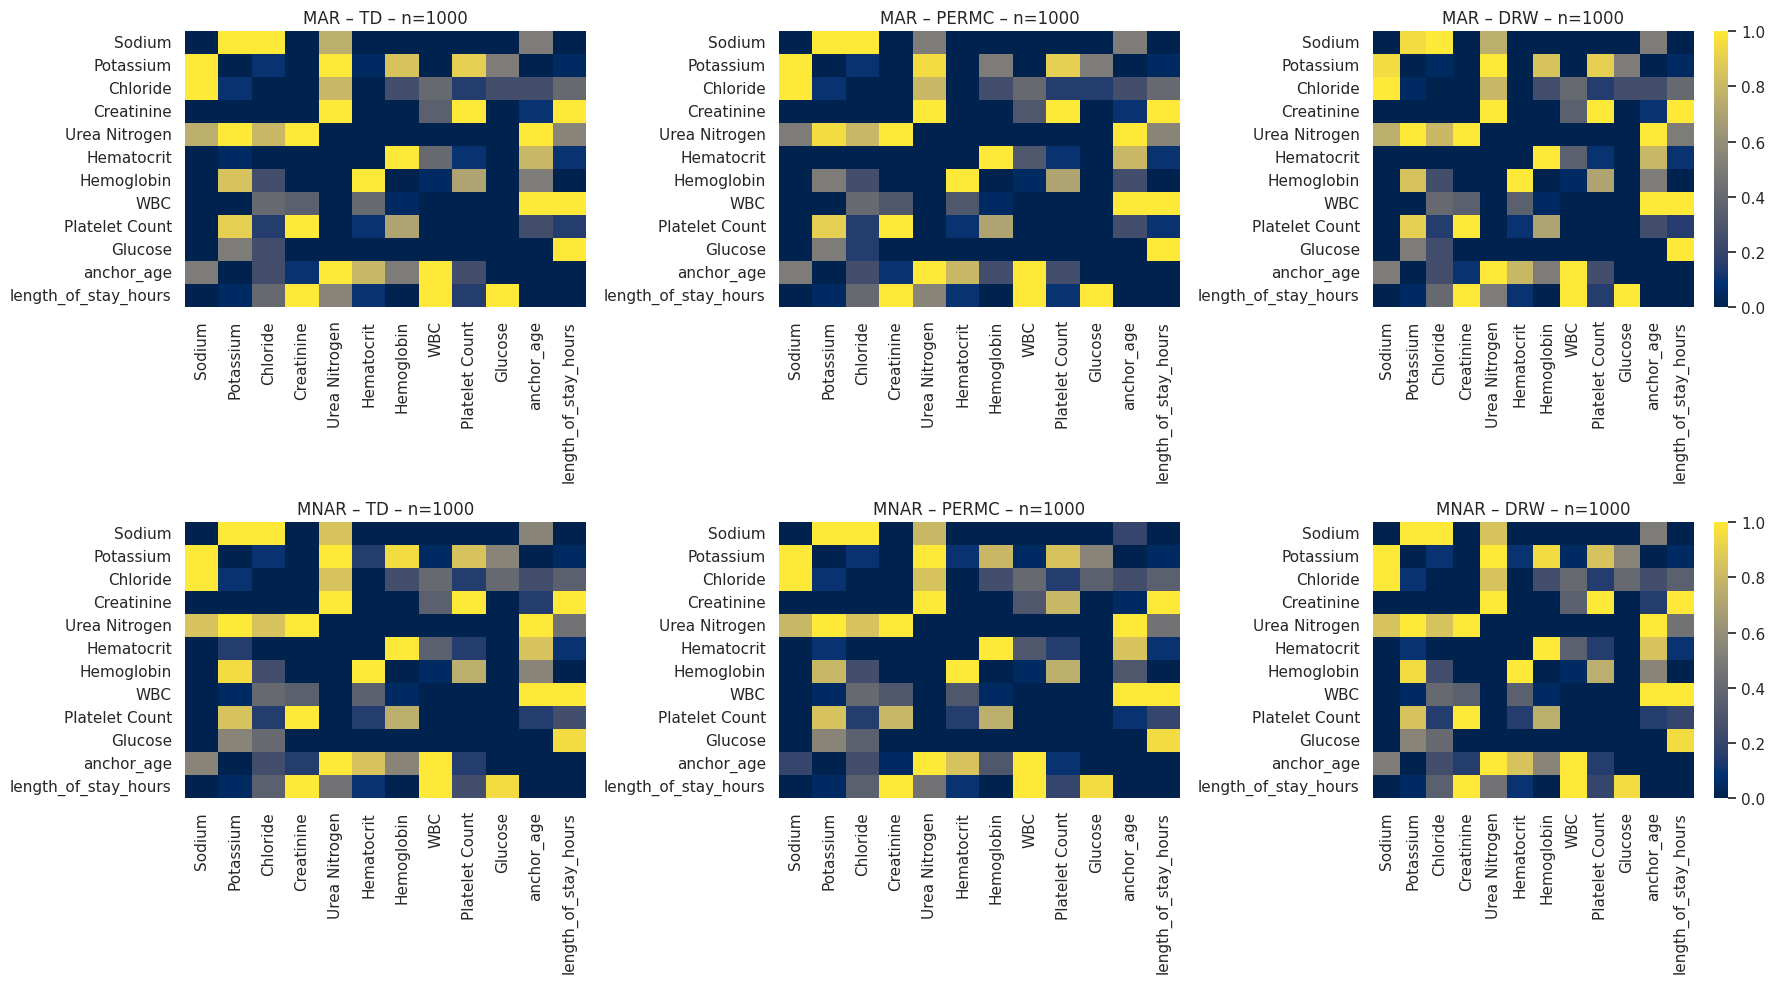

In [24]:
methods = ["td", "permc", "drw"]
modes = ["MAR", "MNAR"]
n = 1000   # or any sample size you want to visualize

fig, axes = plt.subplots(len(modes), len(methods), figsize=(18, 10))

for i, mode in enumerate(modes):
    for j, method in enumerate(methods):

        # Compute edge frequency matrix
        F = edge_frequency_matrix(all_skeletons[(mode, method, n)])

        ax = axes[i, j]
        sns.heatmap(
            F,
            ax=ax,
            xticklabels=mvpc_vars,
            yticklabels=mvpc_vars,
            cmap="cividis",
            vmin=0,
            vmax=1,
            cbar=(j == len(methods)-1)  # show colorbar only on last column
        )

        ax.set_title(f"{mode} – {method.upper()} – n={n}")
        ax.tick_params(axis='x', rotation=90)
        ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


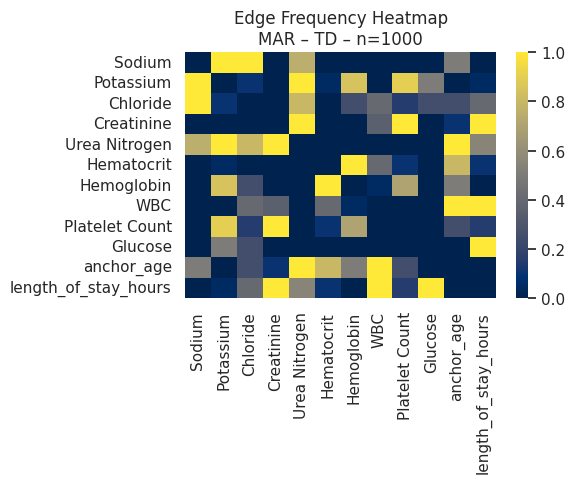

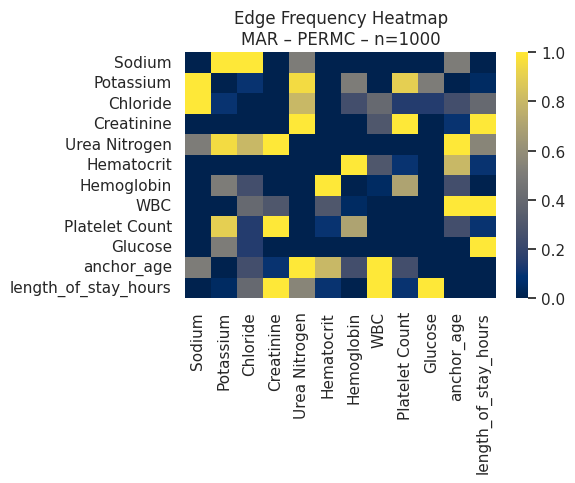

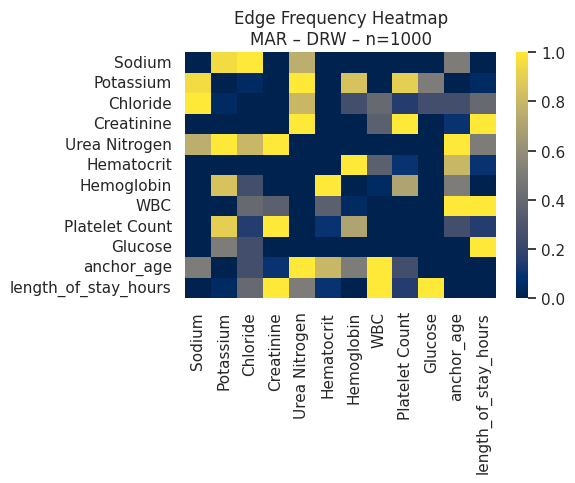

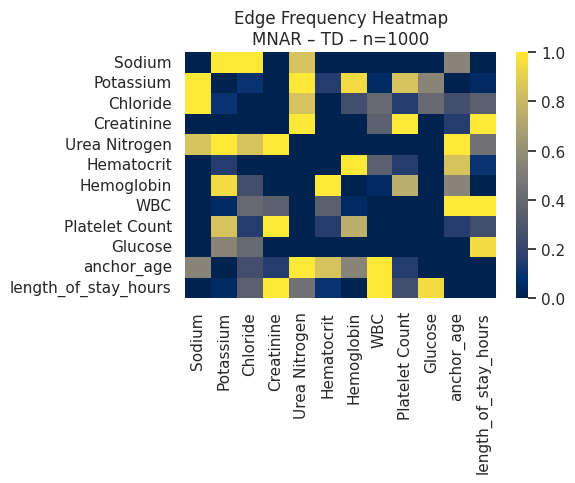

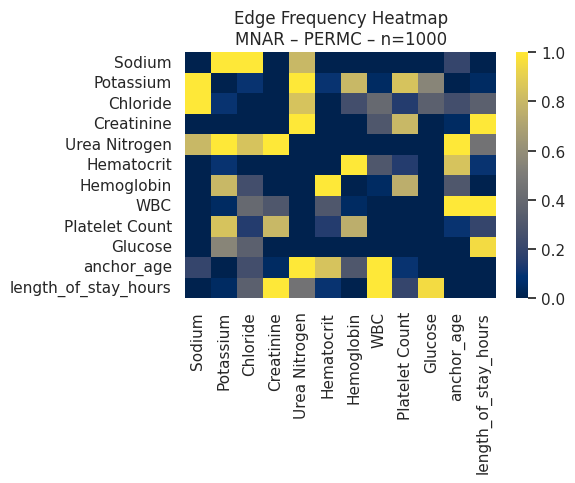

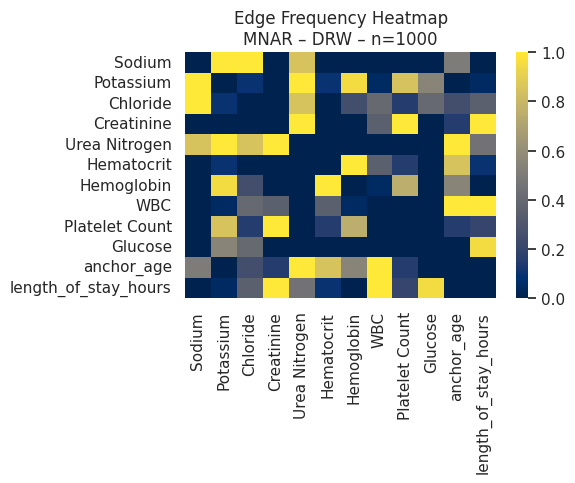

In [25]:
methods = ["td", "permc", "drw"]
modes = ["MAR", "MNAR"]
n = 1000   
for mode in modes:
    for method in methods:

        # Compute edge frequency matrix
        F = edge_frequency_matrix(all_skeletons[(mode, method, n)])

        plt.figure(figsize=(6, 5))
        sns.heatmap(
            F,
            xticklabels=mvpc_vars,
            yticklabels=mvpc_vars,
            cmap="cividis",
            vmin=0,
            vmax=1,
            cbar=True
        )

        plt.title(f"Edge Frequency Heatmap\n{mode} – {method.upper()} – n={n}")
        plt.xticks(rotation=90)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()


In [26]:
for mode in modes:
    for method in methods:
        F = edge_frequency_matrix(all_skeletons[(mode, method, n)])
        print(f"\n=== {mode} – {method.upper()} – n={n} ===")
        display(pd.DataFrame(F, index=mvpc_vars, columns=mvpc_vars).round(2))



=== MAR – TD – n=1000 ===


,Sodium,Potassium,Chloride,Creatinine,Urea Nitrogen,Hematocrit,Hemoglobin,WBC,Platelet Count,Glucose,anchor_age,length_of_stay_hours
Sodium,0.00,1.00,1.00,0.00,0.75,0.00,0.00,0.00,0.00,0.00,0.50,0.00
Potassium,1.00,0.00,0.10,0.00,1.00,0.05,0.85,0.00,0.90,0.50,0.00,0.05
Chloride,1.00,0.10,0.00,0.00,0.80,0.00,0.25,0.40,0.15,0.25,0.25,0.40
Creatinine,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.35,1.00,0.00,0.10,1.00
Urea Nitrogen,0.75,1.00,0.80,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.55
Hematocrit,0.00,0.05,0.00,0.00,0.00,0.00,1.00,0.40,0.10,0.00,0.80,0.10
Hemoglobin,0.00,0.85,0.25,0.00,0.00,1.00,0.00,0.05,0.70,0.00,0.50,0.00
WBC,0.00,0.00,0.40,0.35,0.00,0.40,0.05,0.00,0.00,0.00,1.00,1.00
Platelet Count,0.00,0.90,0.15,1.00,0.00,0.10,0.70,0.00,0.00,0.00,0.25,0.15
Glucose,0.00,0.50,0.25,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00



=== MAR – PERMC – n=1000 ===


,Sodium,Potassium,Chloride,Creatinine,Urea Nitrogen,Hematocrit,Hemoglobin,WBC,Platelet Count,Glucose,anchor_age,length_of_stay_hours
Sodium,0.0,1.00,1.00,0.0,0.50,0.0,0.00,0.00,0.00,0.00,0.50,0.00
Potassium,1.0,0.00,0.10,0.0,0.95,0.0,0.50,0.00,0.90,0.50,0.00,0.05
Chloride,1.0,0.10,0.00,0.0,0.80,0.0,0.25,0.40,0.15,0.15,0.25,0.40
Creatinine,0.0,0.00,0.00,0.0,1.00,0.0,0.00,0.30,1.00,0.00,0.10,1.00
Urea Nitrogen,0.5,0.95,0.80,1.0,0.00,0.0,0.00,0.00,0.00,0.00,1.00,0.55
Hematocrit,0.0,0.00,0.00,0.0,0.00,0.0,1.00,0.30,0.10,0.00,0.80,0.10
Hemoglobin,0.0,0.50,0.25,0.0,0.00,1.0,0.00,0.05,0.70,0.00,0.25,0.00
WBC,0.0,0.00,0.40,0.3,0.00,0.3,0.05,0.00,0.00,0.00,1.00,1.00
Platelet Count,0.0,0.90,0.15,1.0,0.00,0.1,0.70,0.00,0.00,0.00,0.25,0.10
Glucose,0.0,0.50,0.15,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,1.00



=== MAR – DRW – n=1000 ===


...

,Sodium,Potassium,Chloride,Creatinine,Urea Nitrogen,Hematocrit,Hemoglobin,WBC,Platelet Count,Glucose,anchor_age,length_of_stay_hours
Sodium,0.00,1.00,1.00,0.00,0.85,0.00,0.00,0.00,0.00,0.00,0.55,0.00
Potassium,1.00,0.00,0.10,0.00,1.00,0.15,0.95,0.05,0.85,0.55,0.00,0.05
Chloride,1.00,0.10,0.00,0.00,0.85,0.00,0.25,0.40,0.15,0.40,0.25,0.35
Creatinine,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.35,1.00,0.00,0.15,1.00
Urea Nitrogen,0.85,1.00,0.85,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.45
Hematocrit,0.00,0.15,0.00,0.00,0.00,0.00,1.00,0.35,0.15,0.00,0.85,0.10
Hemoglobin,0.00,0.95,0.25,0.00,0.00,1.00,0.00,0.05,0.75,0.00,0.55,0.00
WBC,0.00,0.05,0.40,0.35,0.00,0.35,0.05,0.00,0.00,0.00,1.00,1.00
Platelet Count,0.00,0.85,0.15,1.00,0.00,0.15,0.75,0.00,0.00,0.00,0.15,0.25
Glucose,0.00,0.55,0.40,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.95



=== MNAR – PERMC – n=1000 ===


,Sodium,Potassium,Chloride,Creatinine,Urea Nitrogen,Hematocrit,Hemoglobin,WBC,Platelet Count,Glucose,anchor_age,length_of_stay_hours
Sodium,0.0,1.00,1.00,0.00,0.80,0.00,0.00,0.00,0.00,0.00,0.20,0.00
Potassium,1.0,0.00,0.10,0.00,1.00,0.10,0.80,0.05,0.85,0.55,0.00,0.05
Chloride,1.0,0.10,0.00,0.00,0.85,0.00,0.25,0.40,0.15,0.35,0.25,0.35
Creatinine,0.0,0.00,0.00,0.00,1.00,0.00,0.00,0.30,0.80,0.00,0.05,1.00
Urea Nitrogen,0.8,1.00,0.85,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.45
Hematocrit,0.0,0.10,0.00,0.00,0.00,0.00,1.00,0.30,0.15,0.00,0.85,0.10
Hemoglobin,0.0,0.80,0.25,0.00,0.00,1.00,0.00,0.05,0.75,0.00,0.30,0.00
WBC,0.0,0.05,0.40,0.30,0.00,0.30,0.05,0.00,0.00,0.00,1.00,1.00
Platelet Count,0.0,0.85,0.15,0.80,0.00,0.15,0.75,0.00,0.00,0.00,0.10,0.20
Glucose,0.0,0.55,0.35,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.95



=== MNAR – DRW – n=1000 ===


,Sodium,Potassium,Chloride,Creatinine,Urea Nitrogen,Hematocrit,Hemoglobin,WBC,Platelet Count,Glucose,anchor_age,length_of_stay_hours
Sodium,0.00,1.00,1.00,0.00,0.85,0.00,0.00,0.00,0.00,0.00,0.50,0.00
Potassium,1.00,0.00,0.10,0.00,1.00,0.10,0.95,0.05,0.85,0.55,0.00,0.05
Chloride,1.00,0.10,0.00,0.00,0.85,0.00,0.25,0.40,0.15,0.40,0.25,0.35
Creatinine,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.35,1.00,0.00,0.15,1.00
Urea Nitrogen,0.85,1.00,0.85,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.45
Hematocrit,0.00,0.10,0.00,0.00,0.00,0.00,1.00,0.35,0.15,0.00,0.85,0.10
Hemoglobin,0.00,0.95,0.25,0.00,0.00,1.00,0.00,0.05,0.75,0.00,0.55,0.00
WBC,0.00,0.05,0.40,0.35,0.00,0.35,0.05,0.00,0.00,0.00,1.00,1.00
Platelet Count,0.00,0.85,0.15,1.00,0.00,0.15,0.75,0.00,0.00,0.00,0.15,0.20
Glucose,0.00,0.55,0.40,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.95


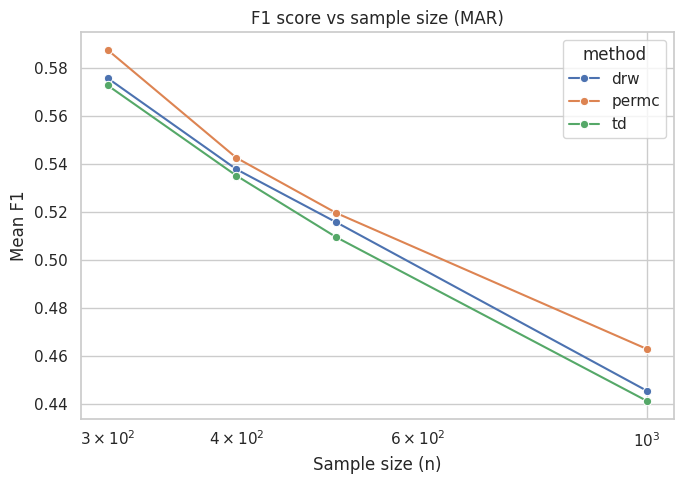

In [ ]:
# -------------------------------------------------------------------
# F1 vs sample size
# -------------------------------------------------------------------
plt.figure(figsize=(7,5))
sub = summary_metrics[summary_metrics["mode"] == "MAR"]

sns.lineplot(
    data=sub,
    x="n",
    y="mean_f1",
    hue="method",
    marker="o",
    errorbar="sd"   # fixed
)

plt.xscale("log")
plt.title("F1 score vs sample size (MAR)")
plt.xlabel("Sample size (n)")
plt.ylabel("Mean F1")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
sub = summary_metrics[summary_metrics["mode"] == "MNAR"]

sns.lineplot(
    data=sub,
    x="n",
    y="mean_f1",
    hue="method",
    marker="o",
    errorbar="sd"
)

plt.xscale("log")
plt.title("F1 score vs sample size (MNAR)")
plt.xlabel("Sample size (n)")
plt.ylabel("Mean F1")
plt.tight_layout()
plt.show()

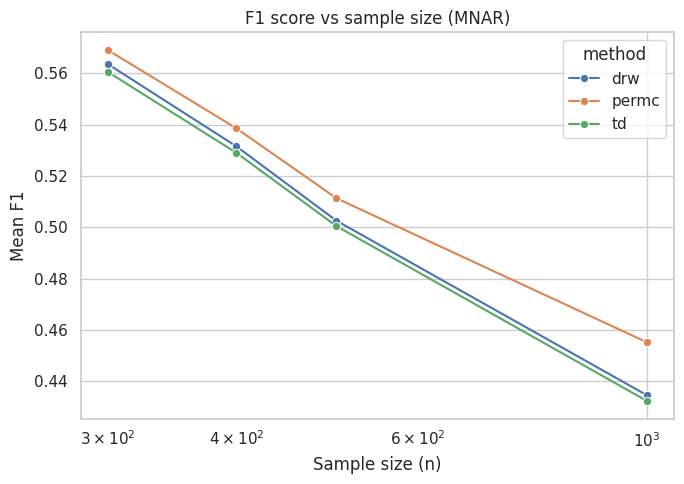

In [ ]:
# -------------------------------------------------------------------
# SHD vs sample size
# -------------------------------------------------------------------
plt.figure(figsize=(7,5))
sub = summary_metrics[summary_metrics["mode"] == "MAR"]

sns.lineplot(
    data=sub,
    x="n",
    y="mean_shd",
    hue="method",
    marker="o"
)

plt.xscale("log")
plt.title("SHD vs sample size (MAR)")
plt.xlabel("Sample size (n)")
plt.ylabel("Mean SHD")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
sub = summary_metrics[summary_metrics["mode"] == "MNAR"]

sns.lineplot(
    data=sub,
    x="n",
    y="mean_shd",
    hue="method",
    marker="o"
)

plt.xscale("log")
plt.title("SHD vs sample size (MNAR)")
plt.xlabel("Sample size (n)")
plt.ylabel("Mean SHD")
plt.tight_layout()
plt.show()